#Trabalho prático # 1
##Introdução à Computação Numérica

###Tópico: Polinômios de Taylor e Diferenciação numérica


**Instruções:**

**Faça uma cópia deste notebook no seu drive, preencha-o com seus dados, escreva e execute seus códigos antes de entregar o trabalho.**

**Inclua  um relatório, na parte final do notebook,** com suas conclusões, respostas, observações e comentários relacionados com os tópicos e questões abordadas nas tarefas.  

**A elaboração dos códigos pode ser realizada em duplas, mas o resto do trabalho é individual.**

**Não é permitido o uso de IA no desenvolvimento do trabalho.**

*Se você fez o seu trabalho em dupla inclua essa informação no relatório. Além disso, se você  também recebeu ajuda de um(a) colega/amigo(a) ou consultou/usou informações da internet ou outras fontes, coloque referências à elas no seu relatório.*


**Entrega do trabalho:**

*Data de entrega: 26/setembro/2026*

---


##Tarefa #1: Implementação

As seguintes fórmulas fornecem aproximações por diferenças finitas das derivadas de primeira e segunda ordens com erros de ordem quadrática.

i)  
$$f'(x_0) =  \frac{-f(x_0+2\Delta x) + 4f(x_0+\Delta x) - 3 f(x_0)}{2\Delta x} + O(\Delta x)^2$$
$$f'(x_0) = \frac{f(x_0+\Delta x)-f(x_0-\Delta x)}{2\Delta x}+O(\Delta x)^2$$

ii)
$$f''(x_0) = \frac{-f(x_0+3\Delta x)+4f(x_0+2\Delta x)-5f(x_0+\Delta x)+2f(x_0)}{(\Delta x)^2}+O(\Delta x)^2$$
$$f''(x_0) = \frac{f(x_0+\Delta x)-2f(x_0)+f(x_0-\Delta x)}{(\Delta x)^2}+O(\Delta x)^2$$

a) Implemente funções em Python para cada uma das aproximações **apresentadas  acima**. Use como parâmetros de entrada uma lista com os valores da função que serão utilizados no cálculo da aproximação da derivada correspondente, ou seja os $𝑓_𝑗=𝑓(x_0+𝑗\Delta x)$ correspondentes, e o incremento  Δ𝑥.

b) Teste a acurácia dessas fórmulas aproximando a primeira e a segunda derivadas da função  $𝑓(𝑥)=\mathrm{e}^{\mathrm{sen}{x}} (\cos{x})$  em 3 pontos do intervalo  $[0,\pi]$  e  valores de  Δ𝑥 = 0.1, 0.01, 0.001 e 0.0001, respectivamente.

c) Determine os erros absolutos dessas aproximações (comparando com os valores exatos). **Explique os resultados observados no seu relatório.**

In [3]:

import math as m


#a)
def derivada_avancada1(deltax,fdex, fmaisdelta, fmais2delta):
  return (-fmais2delta + 4*fmaisdelta - 3*fdex)/(2*deltax)

def derivada_central1(deltax, fmaisdelta, fmenosdelta):
  return (fmaisdelta - fmenosdelta)/(2*deltax)

def derivada_avancada2(deltax,fmais3delta, fmais2delta, fmaisdelta, fdex):
  return (-fmais3delta + 4*fmais2delta - 5*fmaisdelta +2*fdex )/(deltax**2)

def derivada_central2(deltax, fmaisdelta, fmenosdelta, fdex):
  return (fmaisdelta - 2* fdex + fmenosdelta)/(deltax**2)

def formula(x):
  return (m.e**m.sin(x))*(m.cos(x))

def derivadaExata(x):
  return (m.e**m.sin(x)) * (m.cos(x)**2 - m.sin(x))

def derivada2Exata(x):
  return -(m.e**m.sin(x)) * m.sin(x) * m.cos(x) * (m.sin(x) + 3)

#b)

x0s = [m.pi/6, m.pi/2, 5*m.pi/6]
listaDelta = [0.1, 0.01, 0.001, 0.0001]
for x0 in x0s:
  print(f"x0 = {x0}")

  exata1 = derivadaExata(x0)
  exata2 = derivada2Exata(x0)
  print(f" A primeira derivada é {exata1}")
  print(f" A segunda derivada é {exata2}")

  for delta in listaDelta:
    d0 = formula(x0) #fdex
    d1 = formula((x0) + delta) #fmaisdelta
    d2 = formula(x0 + 2*delta) #fmais2delta
    d3 = formula(x0 + 3*delta) #fmais3delta
    dMinus = formula(x0 - delta) #fmenosdelta

    d1_avanc = derivada_avancada1(delta, d0, d1, d2)
    d1_cent = derivada_central1(delta, d1, dMinus)

    d2_avanc = derivada_avancada2(delta, d3, d2, d1, d0)
    d2_cent = derivada_central2(delta, d1, dMinus, d0)

    print(f"Delta = {delta}")
    print(f"f`avançada = {d1_avanc} --- erro = {abs(d1_avanc - exata1)}")
    print(f"f`central = {d1_cent} --- erro = {abs(d1_cent - exata1)}")
    print(f"f``avançada = {d2_avanc} --- erro = {abs(d2_avanc - exata2)}")
    print(f"f``cent = {d2_cent} --- erro = {abs(d2_cent - exata2)}\n")
  print()


x0 = 0.5235987755982988
 A primeira derivada é 0.41218031767503227
 A segunda derivada é -2.498710382325624
Delta = 0.1
f`avançada = 0.4299581596106883 --- erro = 0.017777841935656014
f`central = 0.4027720889849351 --- erro = 0.009408228690097165
f``avançada = -2.56836876161679 --- erro = 0.06965837929116603
f``cent = -2.4968289018646668 --- erro = 0.0018814804609572633

Delta = 0.01
f`avançada = 0.4123686228877599 --- erro = 0.00018830521272761302
f`central = 0.4120858634487967 --- erro = 9.445422623555189e-05
f``avançada = -2.498960574315312 --- erro = 0.00025019198968800893
f``cent = -2.498691788488383 --- erro = 1.8593837241009936e-05

Delta = 0.001
f`avançada = 0.4121822062717051 --- erro = 1.8885966728277026e-06
f`central = 0.4121793730953449 --- erro = 9.44579687356395e-07
f``avançada = -2.498712472043252 --- erro = 2.0897176278289464e-06
f``cent = -2.4987101965301406 --- erro = 1.857954834427744e-07

Delta = 0.0001
f`avançada = 0.41218033656420516 --- erro = 1.8889172892500028e

##Tarefa #2: Aplicação

Um avião está sendo monitorado por um radar, os dados da posição são obtidos em coordenadas polares $r$ e $\theta$.
Use os dados da tabela abaixo para determinar os vetores velocidade e aceleração $\vec{v}$ e $\vec{a}$, respectivamente, para os tempos tabelados.
Sabemos que a velocidade e aceleração em coordenadas polares são dadas pelas seguintes equações:

$\vec{v} = r'\,\vec{e_r} + r \theta'\,\vec{e_\theta},\quad \vec{a} = (r''-r\theta')\,\vec{e_r} + (r \theta''+2 r'\theta')\,\vec{e_\theta}$,

em que $\vec{e_r}$ e $\vec{e_\theta}$ são vetores unitários na direção radial e transversal, respectivamente.

a) Use as aproximações por diferenças finitas de segunda ordem implementadas na Tarefa #1 para aproximar as componentes radial e transversal da velocidade e da aceleração.

b) **Bonus:** Calcule as componentes da velocidade e da aceleração nas coordenadas cartesianas correspondentes. Explique o procedimento adotado.



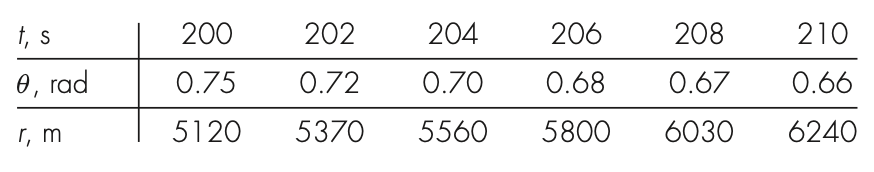

**Observação**: Sempre que for possível dê preferência às fórmulas centradas.

In [4]:
tempo = [200, 202, 204, 206, 208, 210]
teta = [0.75, 0.72, 0.70, 0.68, 0.67, 0.66]
r = [5120, 5370, 5560, 5800, 6030, 6240]
delta = 2

for i in range(len(tempo)):
  if i == 0:
    r1 = derivada_avancada1(delta, r[i], r[i+1], r[i+2])
    teta1 = derivada_avancada1(delta, teta[i], teta[i+1], teta[i+2])

    r2 = derivada_avancada2(delta, r[i+3], r[i+2], r[i+1], r[i])
    teta2 = derivada_avancada2(delta, teta[i+3], teta[i+2], teta[i+1], teta[i])

  elif i == len(tempo) - 1:
     r1 = derivada_avancada1(-delta, r[i], r[i-1], r[i-2])
     teta1 = derivada_avancada1(-delta, teta[i], teta[i-1], teta[i-2])

     r2 = derivada_avancada2(-delta, r[i-3], r[i-2], r[i-1], r[i])
     teta2 = derivada_avancada2(-delta, teta[i-3], teta[i-2], teta[i-1], teta[i])

  else:
    r1 = derivada_central1(delta, r[i+1], r[i-1])
    teta1 = derivada_central1(delta, teta[i+1], teta[i-1])

    r2 = derivada_central2(delta, r[i+1], r[i-1], r[i])
    teta2 = derivada_central2(delta, teta[i+1], teta[i-1], teta[i])

  velocidade = r1
  velocidadeT = r[i] * teta1

  aceleracao = r2 - r[i] * teta1
  aceleracaoT = r[i] * teta2 + 2 * r1 * teta1

  print(f" tempo = {tempo[i]}")
  print(f" velocidade radial = {velocidade}")
  print(f" velocidade transversal = {velocidadeT}")
  print(f" aceleração radial = {aceleracao}")
  print(f" aceleração transversal = {aceleracaoT}")
  print()

  ##B)
  velX = velocidade * m.cos(teta[i]) - velocidadeT * m.sin(teta[i])
  velY = velocidade * m.sin(teta[i]) + velocidadeT * m.cos(teta[i])

  aceX = aceleracao * m.cos(teta[i]) - aceleracaoT * m.sin(teta[i])
  aceY = aceleracao * m.sin(teta[i]) + aceleracaoT * m.cos(teta[i])

  print(f" velocidade em x = {velX}")
  print(f" velocidade em y = {velY}")

  print(f" aceleração em x = {aceX}")
  print(f" aceleração em Y = {aceY}")

 tempo = 200
 velocidade radial = 140.0
 velocidade transversal = -89.60000000000036
 aceleração radial = 47.100000000000364
 aceleração transversal = 20.700000000000003

 velocidade em x = 163.51127454042592
 velocidade em y = 29.870103752172156
 aceleração em x = 20.35262339147421
 aceleração em Y = 47.25114518278738
 tempo = 202
 velocidade radial = 110.0
 velocidade transversal = -67.12500000000006
 aceleração radial = 52.12500000000006
 aceleração transversal = 10.675000000000008

 velocidade em x = 126.95982631158364
 velocidade em y = 22.067354348279416
 aceleração em x = 32.14894225817371
 aceleração em Y = 42.395952185092135
 tempo = 204
 velocidade radial = 107.5
 velocidade transversal = -55.599999999999895
 aceleração radial = 68.0999999999999
 aceleração transversal = -2.1499999999998414

 velocidade em x = 118.03903854349807
 velocidade em y = 26.728175765034308
 aceleração em x = 53.47082098163452
 aceleração em Y = 42.22681379822516
 tempo = 206
 velocidade radial = 117

## Relatório

Na tarefa 1, os erros absolutos das aproximações diminuiram à medida que o delta x foi reduzindo nas iterações. Por exemplo, a redução de um fator de 10 no delta x produziu uma redução de erro de maneira significativa. Entretanto, para valores muito pequenos de delta x, pequenas diferenças ainda podem ocorrer devido a questão do arredondamento dos bytes. Portanto, a escolha da aproximação da derivada e o valor de delta x influenciam diretamente na precisão dos resultados finais.

Na tarefa 2, as derivadas de r e teta foram aproximadas usando as formulas feitas na tarefa 1. Além disso, a velocidade e a aceleração em coordenadas cartesianas foram obtidas usando as formulas de que x = r*cos(teta) e y = r * sen(teta) aprendidas na aula de Calculo 2 que usa como base o livro Cálculo - Volume 2 do James Stewart.